<a href="https://colab.research.google.com/github/vivek-kothekar/ML-Lab-Practicals/blob/main/Practical_11_Vivek_Kothekar_(CS23110).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Vivek R. Kothekar (CS23110)
___
**Aim: To implement a complete regression problem by performing data preprocessing, model building, evaluation, and result interpretation.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

path="/content/drive/MyDrive/ML_Data/Heart_Failure_Prediction_dataset - Heart_Failure_Prediction_dataset.csv"
df=pd.read_csv(path)
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np # Added numpy import

# Define target variable
TARGET = 'RestingBP'

# Separate features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Target variable: {TARGET}")
print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Target variable: RestingBP
Numerical features: ['Age', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Data split into training and testing sets.
X_train shape: (734, 11)
X_test shape: (184, 11)


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the full regression pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model using the training data
model_pipeline.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test data
y_pred = model_pipeline.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 13.89
Mean Squared Error (MSE): 338.62
Root Mean Squared Error (RMSE): 18.40
R-squared (R2) Score: 0.02


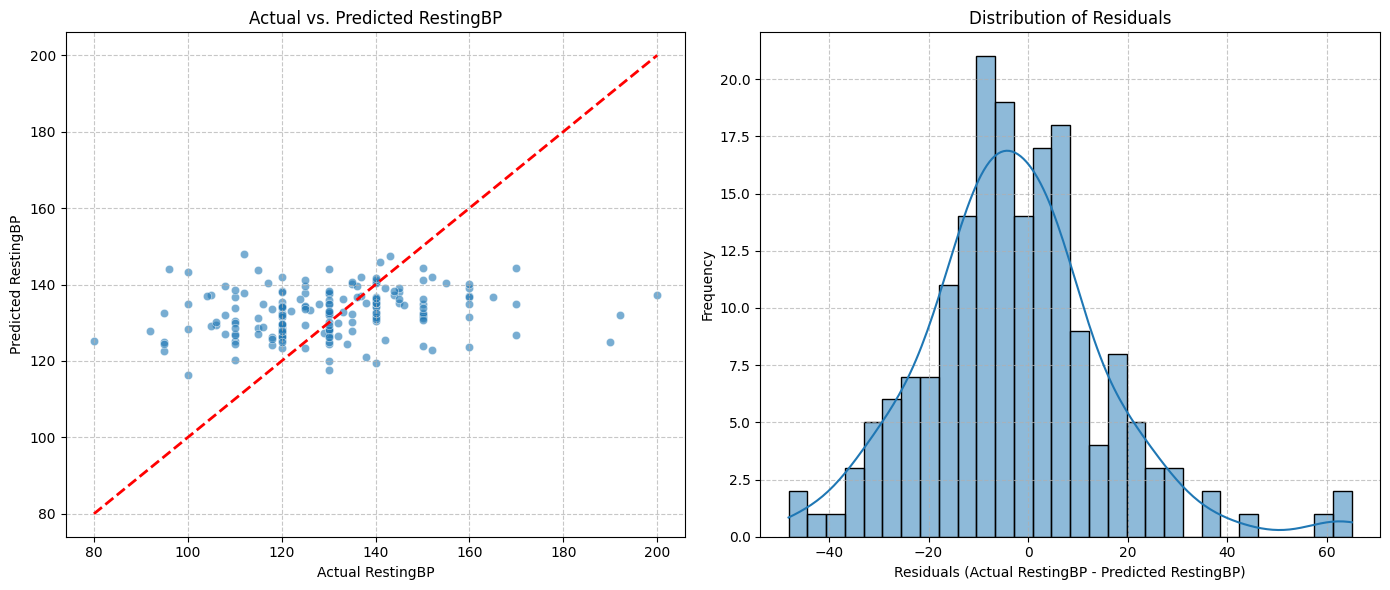

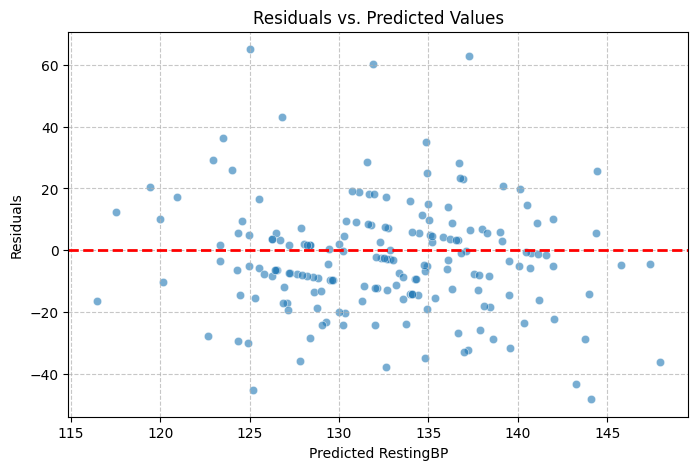

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plotting Predicted vs Actual Values
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.xlabel(f"Actual {TARGET}")
plt.ylabel(f"Predicted {TARGET}")
plt.title(f"Actual vs. Predicted {TARGET}")
plt.grid(True, linestyle='--', alpha=0.7)

# Plotting Residuals Distribution
residuals = y_test - y_pred
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel(f"Residuals (Actual {TARGET} - Predicted {TARGET})")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plotting Residuals vs Predicted Values
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel(f"Predicted {TARGET}")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()